# Week 3 Day 4 — Feature Importance + SHAP Values

## What I built:
- Permutation Importance — accuracy drop when feature shuffled
- SHAP TreeExplainer on Random Forest
- SHAP Summary Plot — all passengers, all features
- SHAP Waterfall Plot — explained one specific passenger
- Compared Built-in vs SHAP importance

## Key concepts:

**Permutation Importance:**
- Shuffle one feature → measure accuracy drop
- Higher drop = more important feature
- Title most important (0.0374 drop)

**SHAP Values:**
- Each feature's contribution to one prediction
- Positive SHAP = pushed prediction up
- Negative SHAP = pushed prediction down
- Baseline = average prediction across all passengers = 0.383

**Waterfall Plot — Passenger 1 (Mrs, 38, 1st class):**
- Baseline: 0.383
- Title=Mrs pushed up most
- 3 features pushed down slightly
- Final prediction: 0.9808 (98% confident — correct ✅)

**Built-in vs SHAP importance:**
- Both agree: Title > Sex > Pclass
- Fare overrated by built-in (used often in splits)
- SHAP more trustworthy — measures actual prediction impact

## Key insight:
Title is the single most important feature — encodes both
gender AND social status. More informative than Sex alone.

# Install SHAP:

In [1]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


# Load your trained model and data:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

# load data
df = pd.read_csv('train.csv')

# feature engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].apply(
                       lambda name: name.split(',')[1]
                                        .split('.')[0].strip())
df['Title']      = df['Title'].map({
                       'Mr': 0, 'Miss': 1, 'Mrs': 2,
                       'Master': 3}).fillna(4)

num_cols = ['Age', 'Fare', 'FamilySize', 'Title']
cat_cols = ['Sex', 'Embarked', 'Pclass']

X = df[num_cols + cat_cols]
y = df['Survived']

# build and fit pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=5,
        max_features='sqrt', min_samples_leaf=4,
        random_state=42
    ))
])

rf_pipe.fit(X, y)
print("Model trained successfully")
print(f"Train accuracy: {rf_pipe.score(X, y):.4f}")

Model trained successfully
Train accuracy: 0.8496


# Permutation Importance:

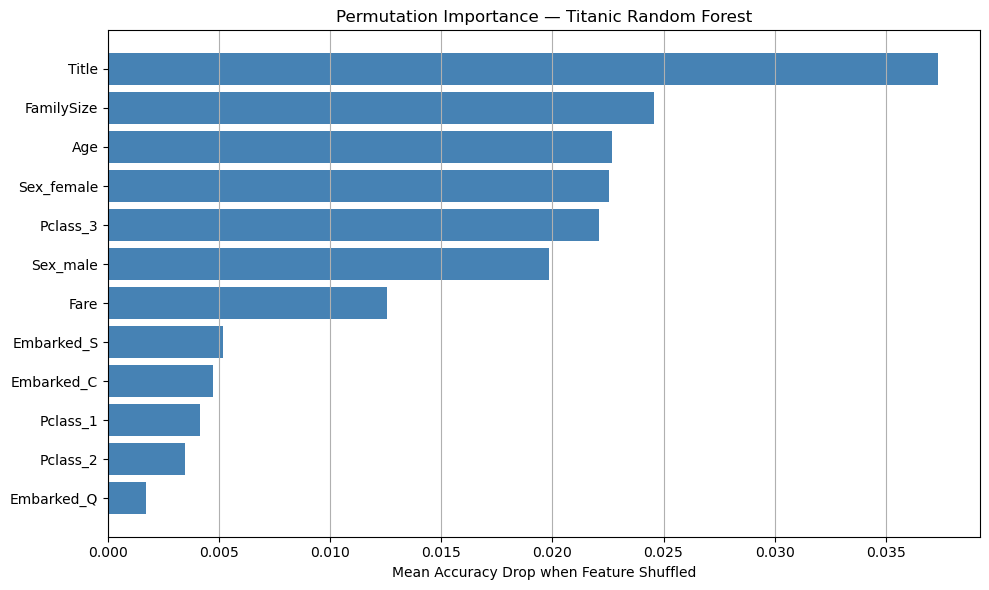


Top 5 most important features:
  Title                : 0.0374
  FamilySize           : 0.0246
  Age                  : 0.0227
  Sex_female           : 0.0226
  Pclass_3             : 0.0221


In [3]:
from sklearn.inspection import permutation_importance

# get feature names after preprocessing
cat_feature_names = rf_pipe.named_steps['preprocessor']\
                           .named_transformers_['cat']\
                           .named_steps['encoder']\
                           .get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + cat_feature_names

# calculate permutation importance
X_transformed = rf_pipe.named_steps['preprocessor'].transform(X)

perm_imp = permutation_importance(
    rf_pipe.named_steps['model'],
    X_transformed, y,
    n_repeats=10,
    random_state=42
)

# sort by importance
sorted_idx = perm_imp.importances_mean.argsort()[::-1]

# plot
plt.figure(figsize=(10, 6))
plt.barh(
    [all_feature_names[i] for i in sorted_idx],
    perm_imp.importances_mean[sorted_idx],
    color='steelblue'
)
plt.xlabel('Mean Accuracy Drop when Feature Shuffled')
plt.title('Permutation Importance — Titanic Random Forest')
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
for i in sorted_idx[:5]:
    print(f"  {all_feature_names[i]:20} : {perm_imp.importances_mean[i]:.4f}")

# SHAP values:

In [4]:
import shap

# get preprocessed data
X_transformed = rf_pipe.named_steps['preprocessor'].transform(X)
model = rf_pipe.named_steps['model']

# create SHAP explainer
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_transformed)

print("shap_values shape:", np.array(shap_values).shape)
print("X_transformed shape:", X_transformed.shape)

shap_values shape: (891, 12, 2)
X_transformed shape: (891, 12)


# SHAP summary plot:

In [5]:
# check shapes first
print("shap_values[1] shape:", np.array(shap_values[1]).shape)
print("X_transformed shape:", X_transformed.shape)
print("all_feature_names length:", len(all_feature_names))

shap_values[1] shape: (12, 2)
X_transformed shape: (891, 12)
all_feature_names length: 12


In [6]:
# correct way to get class 1 shap values
shap_vals_class1 = np.array(shap_values)[:, :, 1]
print("Corrected shape:", shap_vals_class1.shape)  # should be (891, 12)

Corrected shape: (891, 12)


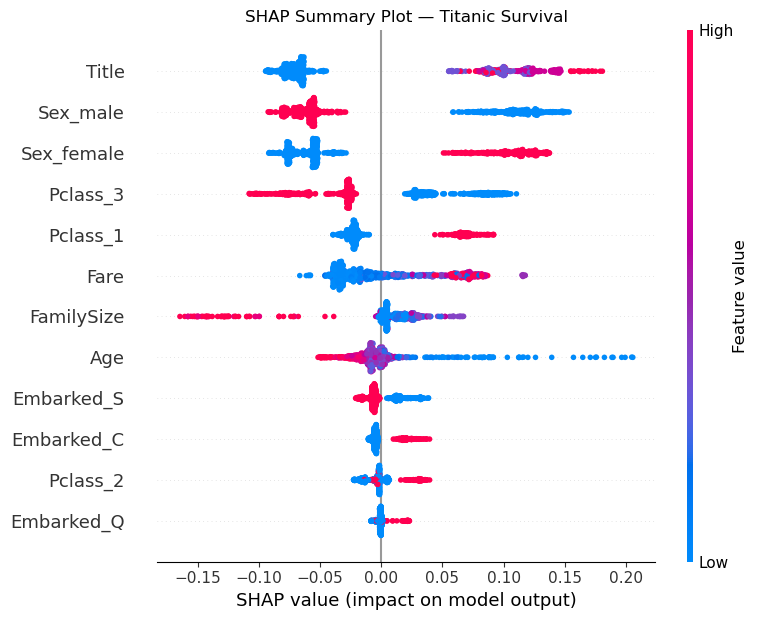

In [7]:
# summary plot — all passengers, all features
plt.figure()
shap.summary_plot(
    shap_vals_class1,      # shape (891, 12) — correct
    X_transformed,
    feature_names=all_feature_names,
    show=False
)
plt.title('SHAP Summary Plot — Titanic Survival')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP waterfall plot for one passenger:

Passenger details:
Age              38.0
Fare          71.2833
FamilySize          2
Title             2.0
Sex            female
Embarked            C
Pclass              1
Name: 1, dtype: object

Actual survival   : 1
Predicted survival: 1
Predicted prob    : 0.9808


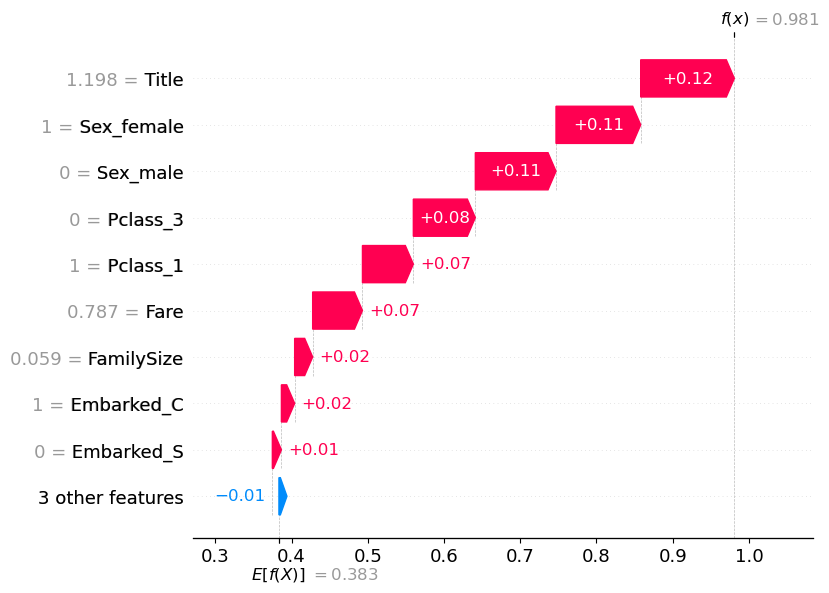

<Figure size 640x480 with 0 Axes>

In [8]:
# pick passenger 1 — let's explain their prediction
passenger_idx = 1

print("Passenger details:")
print(X.iloc[passenger_idx])
print(f"\nActual survival   : {y.iloc[passenger_idx]}")
print(f"Predicted survival: {rf_pipe.predict(X.iloc[[passenger_idx]])[0]}")
print(f"Predicted prob    : {rf_pipe.predict_proba(X.iloc[[passenger_idx]])[0][1]:.4f}")

# waterfall plot
shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_class1[passenger_idx],
        base_values=explainer.expected_value[1],
        data=X_transformed[passenger_idx],
        feature_names=all_feature_names
    )
)
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# Compare SHAP vs Permutation Importance:

In [9]:
# built-in RF feature importance vs permutation vs SHAP
rf_model = rf_pipe.named_steps['model']

# built-in importance
builtin_importance = rf_model.feature_importances_

# mean absolute SHAP values
shap_importance = np.abs(shap_vals_class1).mean(axis=0)

# sort by SHAP importance
sorted_idx = shap_importance.argsort()[::-1]

print("=" * 55)
print("   FEATURE IMPORTANCE COMPARISON")
print("=" * 55)
print(f"  {'Feature':20} {'Built-in':>10} {'SHAP':>10}")
print("-" * 55)
for i in sorted_idx[:7]:
    print(f"  {all_feature_names[i]:20} {builtin_importance[i]:>10.4f} {shap_importance[i]:>10.4f}")
print("=" * 55)

   FEATURE IMPORTANCE COMPARISON
  Feature                Built-in       SHAP
-------------------------------------------------------
  Title                    0.2069     0.0869
  Sex_male                 0.1946     0.0798
  Sex_female               0.1872     0.0778
  Pclass_3                 0.0820     0.0498
  Pclass_1                 0.0452     0.0346
  Fare                     0.1046     0.0341
  FamilySize               0.0700     0.0205
